In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

conn = sqlite3.connect("../database/yieldwatch.db")

runs = pd.read_sql("SELECT * FROM production_runs", conn)
sensors = pd.read_sql("SELECT * FROM sensor_readings", conn)

runs["timestamp"] = pd.to_datetime(runs["timestamp"])
sensors["timestamp"] = pd.to_datetime(sensors["timestamp"])

print("Runs:", runs.shape)
print("Sensors:", sensors.shape)

Runs: (60000, 13)
Sensors: (60000, 11)


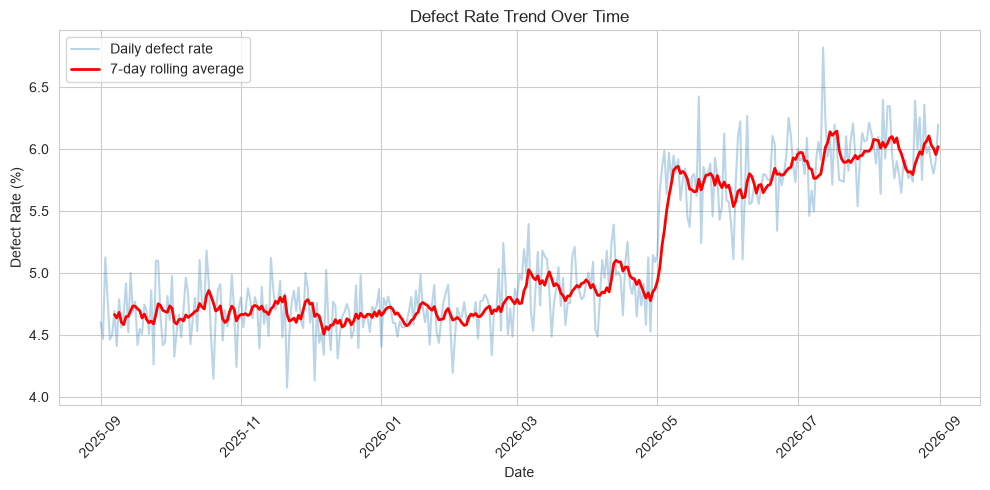

In [2]:
daily = runs.groupby(runs["timestamp"].dt.date).agg(
    produced=("produced_units", "sum"),
    defective=("defective_units", "sum")
).reset_index()
daily["defect_pct"] = daily["defective"] / daily["produced"] * 100
daily["rolling_7day"] = daily["defect_pct"].rolling(7).mean()

plt.figure()
plt.plot(daily["timestamp"], daily["defect_pct"], alpha=0.3, label="Daily defect rate")
plt.plot(daily["timestamp"], daily["rolling_7day"], color="red", linewidth=2, label="7-day rolling average")
plt.title("Defect Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Defect Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

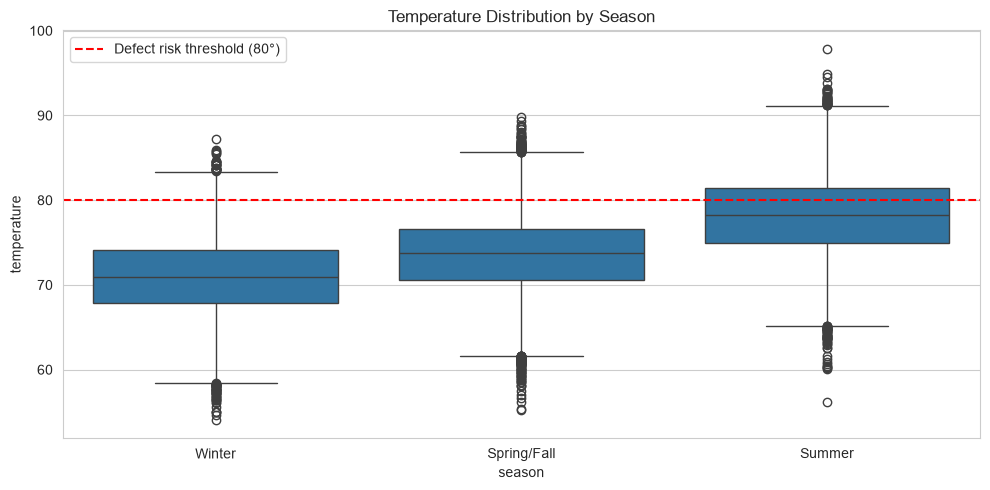

In [3]:
sensors_with_month = sensors.merge(runs[["run_id", "timestamp"]], on="run_id", suffixes=("", "_run"))
sensors_with_month["month"] = sensors_with_month["timestamp"].dt.month

def season_label(m):
    if m in [5,6,7,8]:
        return "Summer"
    elif m in [12,1,2]:
        return "Winter"
    else:
        return "Spring/Fall"

sensors_with_month["season"] = sensors_with_month["month"].apply(season_label)

plt.figure()
sns.boxplot(data=sensors_with_month, x="season", y="temperature", order=["Winter", "Spring/Fall", "Summer"])
plt.axhline(80, color="red", linestyle="--", label="Defect risk threshold (80°)")
plt.title("Temperature Distribution by Season")
plt.legend()
plt.tight_layout()
plt.show()

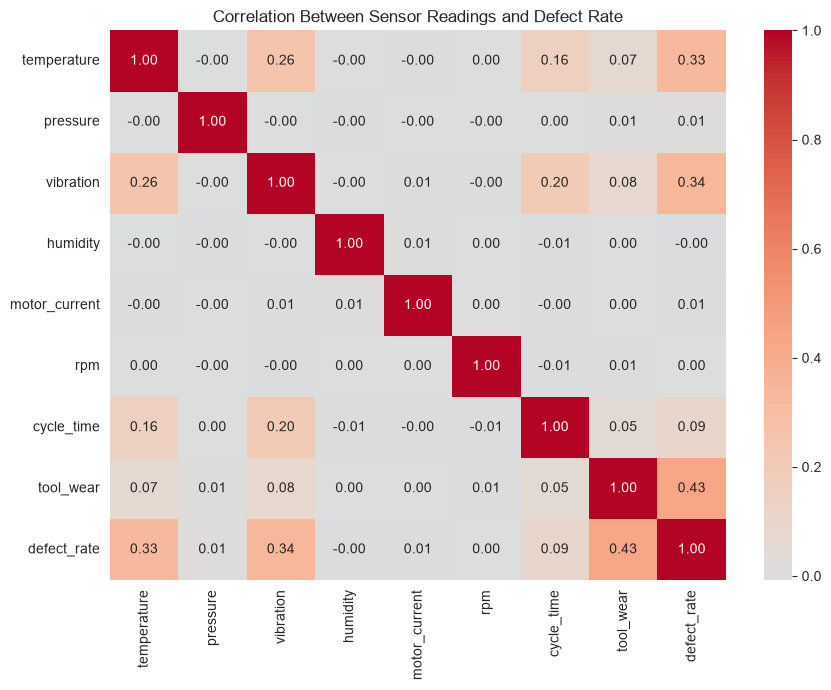

In [4]:
# Merge sensor readings with defect_rate from the runs table
merged = sensors.merge(runs[["run_id", "defect_rate"]], on="run_id")

corr_cols = ["temperature", "pressure", "vibration", "humidity", "motor_current", "rpm", "cycle_time", "tool_wear", "defect_rate"]
corr_matrix = merged[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Sensor Readings and Defect Rate")
plt.tight_layout()
plt.show()

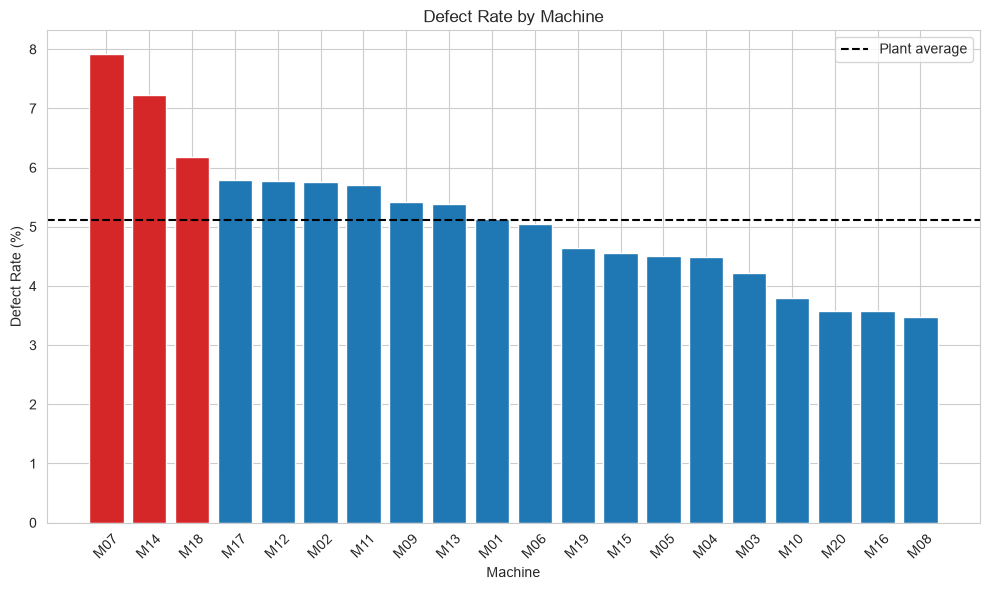

In [5]:
machine_defect = runs.groupby("machine_id").apply(
    lambda g: g["defective_units"].sum() / g["produced_units"].sum() * 100,
    include_groups=False
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ["#d62728" if x in ["M07", "M14", "M18"] else "#1f77b4" for x in machine_defect.index]
plt.bar(machine_defect.index, machine_defect.values, color=colors)
plt.axhline(runs["defective_units"].sum() / runs["produced_units"].sum() * 100,
            color="black", linestyle="--", label="Plant average")
plt.title("Defect Rate by Machine")
plt.xlabel("Machine")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

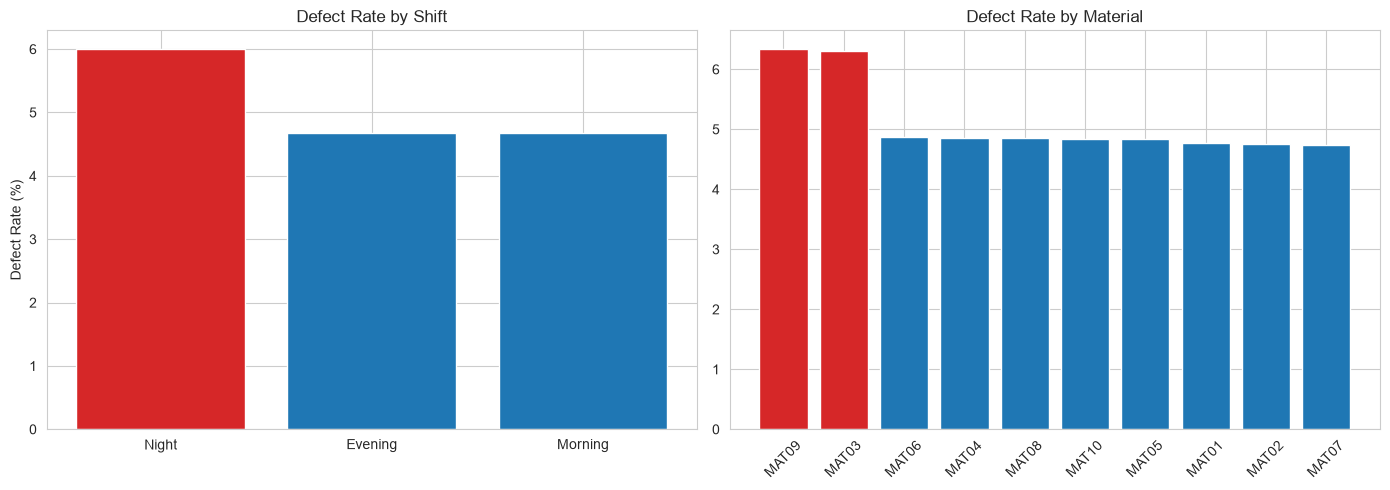

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shift_defect = runs.groupby("shift_id").apply(
    lambda g: g["defective_units"].sum() / g["produced_units"].sum() * 100,
    include_groups=False
).sort_values(ascending=False)

material_defect = runs.groupby("material_id").apply(
    lambda g: g["defective_units"].sum() / g["produced_units"].sum() * 100,
    include_groups=False
).sort_values(ascending=False)

axes[0].bar(shift_defect.index, shift_defect.values, color=["#d62728" if x == "Night" else "#1f77b4" for x in shift_defect.index])
axes[0].set_title("Defect Rate by Shift")
axes[0].set_ylabel("Defect Rate (%)")

axes[1].bar(material_defect.index, material_defect.values, color=["#d62728" if x in ["MAT03","MAT09"] else "#1f77b4" for x in material_defect.index])
axes[1].set_title("Defect Rate by Material")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

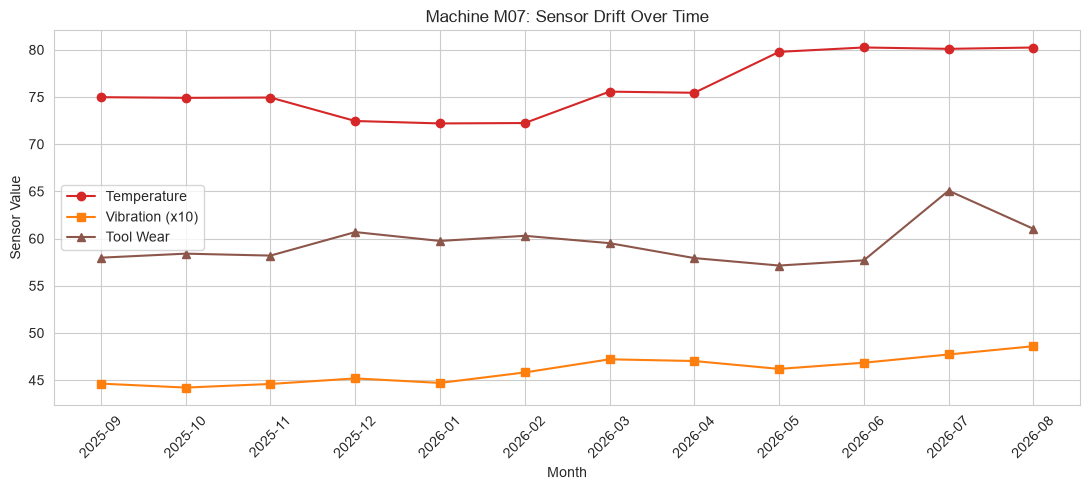

In [7]:
m07_sensors = sensors.merge(runs[["run_id", "timestamp", "machine_id"]], on="run_id", suffixes=("", "_run"))
m07_sensors = m07_sensors[m07_sensors["machine_id"] == "M07"].sort_values("timestamp")
m07_sensors["month"] = m07_sensors["timestamp"].dt.to_period("M")

monthly_avg = m07_sensors.groupby("month")[["temperature", "vibration", "tool_wear"]].mean()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly_avg.index.astype(str), monthly_avg["temperature"], marker="o", label="Temperature", color="tab:red")
ax1.plot(monthly_avg.index.astype(str), monthly_avg["vibration"] * 10, marker="s", label="Vibration (x10)", color="tab:orange")
ax1.plot(monthly_avg.index.astype(str), monthly_avg["tool_wear"], marker="^", label="Tool Wear", color="tab:brown")
ax1.set_title("Machine M07: Sensor Drift Over Time")
ax1.set_xlabel("Month")
ax1.set_ylabel("Sensor Value")
ax1.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()